# Cognifyz Data Science Internship
## Level 2 - Task 2: Price Range Analysis

### Objective

Analyze the distribution of price ranges among restaurants and examine the relationship between price range and aggregate rating.

The analysis will include:

- Distribution of price ranges
- Average rating for each price range
- Relationship between price range and restaurant rating
- Visualizations of the results

### Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Load the cleaned dataset

In [7]:
df = pd.read_csv("Cleaned_Dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (9551, 21)


### Inspect the relevant columns

In [8]:
print("Price Range and Aggregate Rating:")
df[
        [
            "Restaurant Name",
            "Price range",
            "Aggregate rating"
        ]
    ].head(10)


Price Range and Aggregate Rating:


,Restaurant Name,Price range,Aggregate rating
0,Le Petit Souffle,3,4.8
1,Izakaya Kikufuji,3,4.5
2,Heat - Edsa Shangri-La,4,4.4
3,Ooma,4,4.9
4,Sambo Kojin,4,4.8
5,Din Tai Fung,3,4.4
6,Buffet 101,4,4.0
7,Vikings,4,4.2
8,Spiral - Sofitel Philippine Plaza Manila,4,4.9
9,Locavore,3,4.8


### Check the price range categories

In [9]:
print("Price Range Distribution:")
df["Price range"].value_counts().sort_index()

Price Range Distribution:


Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

### Calculate percentages

In [15]:
price_counts = df["Price range"].value_counts().sort_index()

price_percentages = (
    df["Price range"].value_counts(normalize=True).sort_index() * 100
)

print("Price Range Percentages:")
print(price_percentages.round(2))

Price Range Percentages:
Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: proportion, dtype: float64


### Create the price-range distribution graph

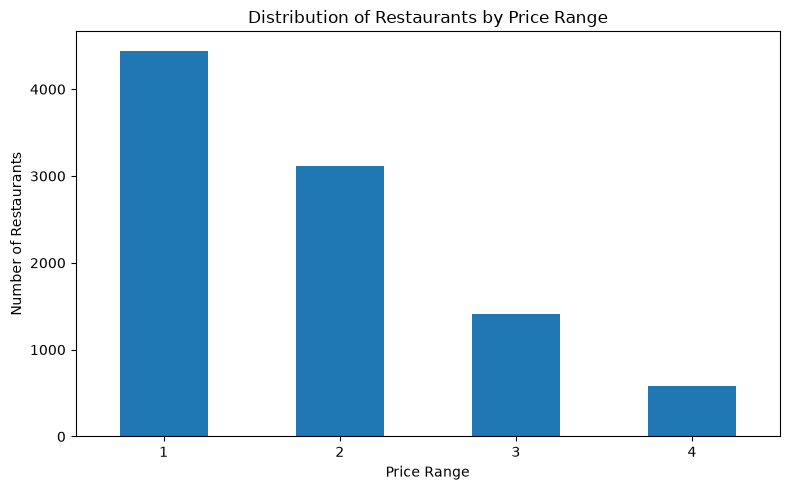

In [16]:
plt.figure(figsize=(8, 5))

price_counts.plot(kind="bar")

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Identify the most common price range 

In [17]:
mc_price_range = price_counts.idxmax()
mc_price_count = price_counts.max()

print("Most common Price Range:", mc_price_range)
print("Number of restaurants:", mc_price_count)

Most common Price Range: 1
Number of restaurants: 4444


### Calculate average rating by price range

In [18]:
avg_rating_by_price = df.groupby(
    "Price range"
)["Aggregate rating"].mean()

print("Average Aggregate Rating by Price Range:")
display(avg_rating_by_price.round(2))

Average Aggregate Rating by Price Range:


Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64

### Create the rating comparison graph

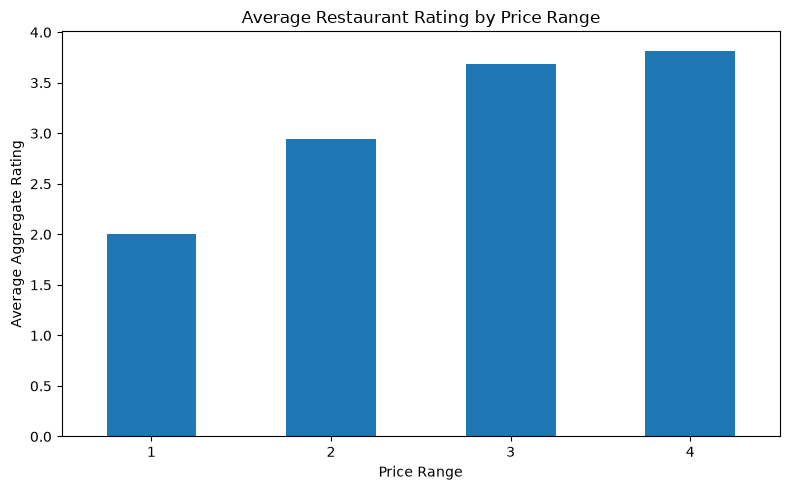

In [20]:
plt.figure(figsize=(8, 5))

avg_rating_by_price.plot(kind="bar")

plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Calculate the highest-rated price range

In [21]:
high_rated_price_range = avg_rating_by_price.idxmax()
high_average_rating = avg_rating_by_price.max()

print("Highest average-rated Price Range:", high_rated_price_range)
print(
    "Highest average Aggregate Rating:",
    round(high_average_rating, 2)
)

Highest average-rated Price Range: 4
Highest average Aggregate Rating: 3.82


### Analyze the relationship between price range and rating

Let's calculate the correlation between the two variables.

In [26]:
price_rating_correlation = df[
    ["Price range", "Aggregate rating"]
].corr()

print("Correlation between Price Range and Aggregate Rating:")
display(price_rating_correlation.round(3))

correlation_value = price_rating_correlation.loc[
    "Price range",
    "Aggregate rating"
]

print(
    "Price Range vs Aggregate Rating correlation:",
    round(correlation_value, 3)
)

Correlation between Price Range and Aggregate Rating:


,Price range,Aggregate rating
Price range,1.000,0.438
Aggregate rating,0.438,1.000


Price Range vs Aggregate Rating correlation: 0.438


### Create a box plot

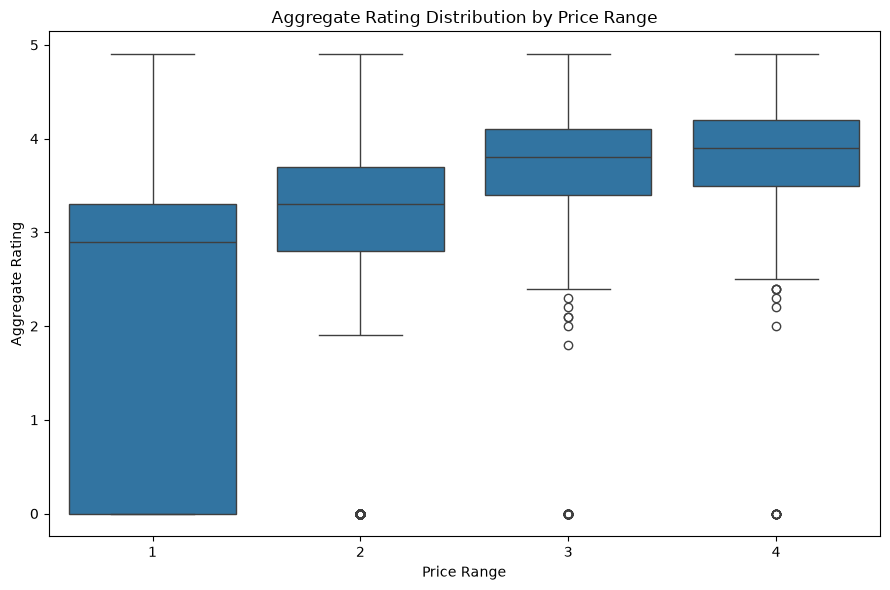

In [25]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    x="Price range",
    y="Aggregate rating",
    data=df
)

plt.title("Aggregate Rating Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

In [28]:
summary_table = pd.DataFrame({
    "Number of Restaurants": price_counts,
    "Percentage (%)": price_percentages.round(2),
    "Average Rating": avg_rating_by_price.round(2)
})

display(summary_table)

,Number of Restaurants,Percentage (%),Average Rating
Price range,,,
1,4444,46.53,2.00
2,3113,32.59,2.94
3,1408,14.74,3.68
4,586,6.14,3.82


## Conclusion

The analysis examined the distribution of restaurants across four price ranges and explored the relationship between price range and aggregate rating.

Price Range 1 has the largest number of restaurants, with 4,444 restaurants, while Price Range 4 has the smallest number, with 586 restaurants.

The average rating varies across the four price ranges. Price Range 4 has the highest average rating of approximately 3.82.

The correlation between Price Range and Aggregate Rating is 0.438, indicating a positive association between the two variables in this dataset.

Overall, the analysis suggests that higher price ranges are associated with higher average ratings in this dataset. However, correlation does not establish causation, and other factors may also influence restaurant ratings.